In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "Dataset for Data Analytics.xlsx")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [2]:
# Check data types
print("Data Types:")
print(df.dtypes)

print("\n" + "="*50)

# Check missing values
print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*50)

# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Data Types:
OrderID                    object
Date               datetime64[ns]
CustomerID                 object
Product                    object
Quantity                    int64
UnitPrice                 float64
ShippingAddress            object
PaymentMethod              object
OrderStatus                object
TrackingNumber             object
ItemsInCart                 int64
CouponCode                 object
ReferralSource             object
TotalPrice                float64
dtype: object

Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Duplicate Rows: 0


In [3]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


OrderID:
OrderID
ORD200000    1
ORD200806    1
ORD200804    1
ORD200803    1
ORD200802    1
            ..
ORD200399    1
ORD200398    1
ORD200397    1
ORD200396    1
ORD201199    1
Name: count, Length: 1200, dtype: int64

CustomerID:
CustomerID
C38840    2
C14847    2
C21191    2
C94569    2
C46651    2
         ..
C99217    1
C30010    1
C70148    1
C39906    1
C57502    1
Name: count, Length: 1189, dtype: int64

Product:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

ShippingAddress:
ShippingAddress
533 Main St    8
895 Main St    6
146 Main St    5
562 Main St    5
636 Main St    5
              ..
520 Main St    1
459 Main St    1
539 Main St    1
556 Main St    1
201 Main St    1
Name: count, Length: 655, dtype: int64

PaymentMethod:
PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

OrderStatus:
OrderSt

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel(
    "Dataset for Data Analytics.xlsx")
numerical_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice"
]

print(df[numerical_columns].describe())

          Quantity    UnitPrice  ItemsInCart   TotalPrice
count  1200.000000  1200.000000  1200.000000  1200.000000
mean      2.945833   356.412750     5.485000  1053.968300
std       1.407557   197.177146     2.281983   819.856558
min       1.000000    11.390000     1.000000    11.390000
25%       2.000000   186.062500     4.000000   410.520000
50%       3.000000   364.210000     5.000000   823.615000
75%       4.000000   521.570000     7.000000  1578.475000
max       5.000000   699.930000    10.000000  3456.400000


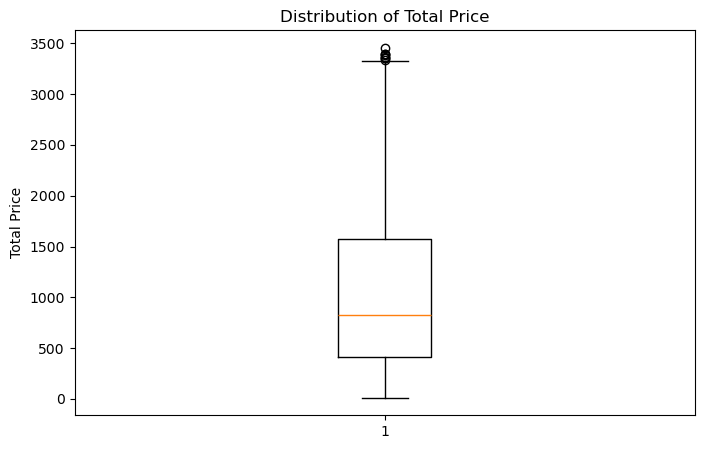

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.boxplot(df["TotalPrice"])
plt.title("Distribution of Total Price")
plt.ylabel("Total Price")
plt.show()

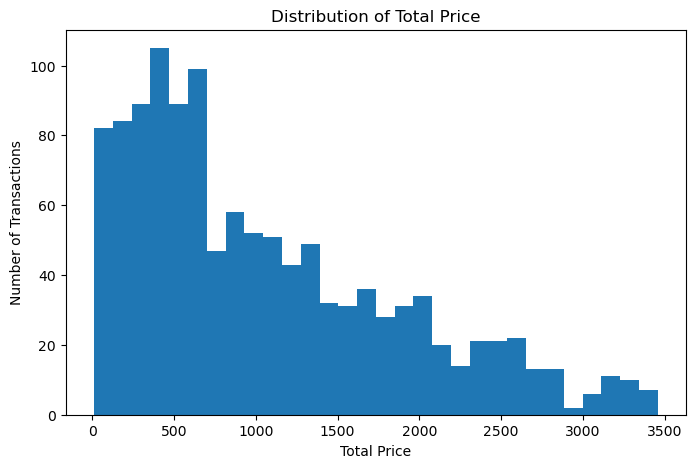

In [3]:
plt.figure(figsize=(8, 5))
plt.hist(df["TotalPrice"], bins=30)
plt.title("Distribution of Total Price")
plt.xlabel("Total Price")
plt.ylabel("Number of Transactions")
plt.show()

In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel(
    "Dataset for Data Analytics.xlsx")
# Customer order frequency
df["CustomerOrderCount"] = df["CustomerID"].map(
    df["CustomerID"].value_counts()
)

# Shipping address order frequency
df["AddressOrderCount"] = df["ShippingAddress"].map(
    df["ShippingAddress"].value_counts()
)

# Check the new features
print(df[[
    "CustomerID",
    "CustomerOrderCount",
    "ShippingAddress",
    "AddressOrderCount"
]].head(10))

  CustomerID  CustomerOrderCount ShippingAddress  AddressOrderCount
0     C72649                   1     928 Main St                  2
1     C75739                   1     823 Main St                  1
2     C81728                   1     512 Main St                  2
3     C33540                   1     275 Main St                  3
4     C81840                   1     668 Main St                  1
5     C37249                   1     934 Main St                  4
6     C83492                   1     986 Main St                  2
7     C41460                   1     706 Main St                  4
8     C26817                   1     904 Main St                  4
9     C31946                   1     102 Main St                  2


In [2]:
# Convert Date into useful features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

# Check the new features
print(df[[
    "Date",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend"
]].head(10))

        Date  Year  Month  Day  DayOfWeek  IsWeekend
0 2023-01-04  2023      1    4          2          0
1 2024-08-23  2024      8   23          4          0
2 2024-02-27  2024      2   27          1          0
3 2023-10-15  2023     10   15          6          1
4 2025-05-08  2025      5    8          3          0
5 2023-10-23  2023     10   23          0          0
6 2025-06-17  2025      6   17          1          0
7 2023-05-12  2023      5   12          4          0
8 2025-04-02  2025      4    2          2          0
9 2023-11-21  2023     11   21          1          0


In [3]:
features_to_check = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount",
    "AddressOrderCount"
]

print(df[features_to_check].describe().T)

                     count         mean         std    min       25%      50%  \
Quantity            1200.0     2.945833    1.407557   1.00    2.0000    3.000   
UnitPrice           1200.0   356.412750  197.177146  11.39  186.0625  364.210   
ItemsInCart         1200.0     5.485000    2.281983   1.00    4.0000    5.000   
TotalPrice          1200.0  1053.968300  819.856558  11.39  410.5200  823.615   
CustomerOrderCount  1200.0     1.018333    0.134210   1.00    1.0000    1.000   
AddressOrderCount   1200.0     2.366667    1.172619   1.00    1.0000    2.000   

                         75%      max  
Quantity               4.000     5.00  
UnitPrice            521.570   699.93  
ItemsInCart            7.000    10.00  
TotalPrice          1578.475  3456.40  
CustomerOrderCount     1.000     2.00  
AddressOrderCount      3.000     8.00  


In [4]:
print(df[features_to_check].describe().T)

                     count         mean         std    min       25%      50%  \
Quantity            1200.0     2.945833    1.407557   1.00    2.0000    3.000   
UnitPrice           1200.0   356.412750  197.177146  11.39  186.0625  364.210   
ItemsInCart         1200.0     5.485000    2.281983   1.00    4.0000    5.000   
TotalPrice          1200.0  1053.968300  819.856558  11.39  410.5200  823.615   
CustomerOrderCount  1200.0     1.018333    0.134210   1.00    1.0000    1.000   
AddressOrderCount   1200.0     2.366667    1.172619   1.00    1.0000    2.000   

                         75%      max  
Quantity               4.000     5.00  
UnitPrice            521.570   699.93  
ItemsInCart            7.000    10.00  
TotalPrice          1578.475  3456.40  
CustomerOrderCount     1.000     2.00  
AddressOrderCount      3.000     8.00  


In [5]:
# Features for anomaly detection
anomaly_features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "AddressOrderCount"
]

# Calculate IQR-based upper bounds
upper_bounds = {}

for col in anomaly_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    upper_bounds[col] = upper_bound
    
    print(f"{col}:")
    print(f"  Q1 = {Q1:.2f}")
    print(f"  Q3 = {Q3:.2f}")
    print(f"  IQR = {IQR:.2f}")
    print(f"  Upper Bound = {upper_bound:.2f}")
    print()

Quantity:
  Q1 = 2.00
  Q3 = 4.00
  IQR = 2.00
  Upper Bound = 7.00

UnitPrice:
  Q1 = 186.06
  Q3 = 521.57
  IQR = 335.51
  Upper Bound = 1024.83

ItemsInCart:
  Q1 = 4.00
  Q3 = 7.00
  IQR = 3.00
  Upper Bound = 11.50

TotalPrice:
  Q1 = 410.52
  Q3 = 1578.47
  IQR = 1167.95
  Upper Bound = 3330.41

AddressOrderCount:
  Q1 = 1.00
  Q3 = 3.00
  IQR = 2.00
  Upper Bound = 6.00



In [6]:
print("Highest TotalPrice transactions:")
print(
    df.nlargest(10, "TotalPrice")[
        [
            "OrderID",
            "TotalPrice",
            "Quantity",
            "UnitPrice",
            "ItemsInCart",
            "CustomerOrderCount",
            "AddressOrderCount",
            "PaymentMethod",
            "OrderStatus"
        ]
    ]
)

Highest TotalPrice transactions:
        OrderID  TotalPrice  Quantity  UnitPrice  ItemsInCart  \
789   ORD200789     3456.40         5     691.28           10   
1122  ORD201122     3390.95         5     678.19            8   
632   ORD200632     3390.80         5     678.16            7   
469   ORD200469     3384.90         5     676.98            5   
328   ORD200328     3370.20         5     674.04            7   
107   ORD200107     3353.75         5     670.75            8   
326   ORD200326     3352.40         5     670.48            5   
1065  ORD201065     3334.00         5     666.80            7   
1031  ORD201031     3322.55         5     664.51            8   
463   ORD200463     3313.90         5     662.78            9   

      CustomerOrderCount  AddressOrderCount PaymentMethod OrderStatus  
789                    1                  1        Online   Delivered  
1122                   2                  2        Online    Returned  
632                    1           

In [7]:
print("\nHighest AddressOrderCount transactions:")
print(
    df.nlargest(10, "AddressOrderCount")[
        [
            "OrderID",
            "TotalPrice",
            "Quantity",
            "UnitPrice",
            "ItemsInCart",
            "CustomerOrderCount",
            "AddressOrderCount",
            "PaymentMethod",
            "OrderStatus"
        ]
    ]
)


Highest AddressOrderCount transactions:
        OrderID  TotalPrice  Quantity  UnitPrice  ItemsInCart  \
98    ORD200098      457.08         2     228.54            3   
513   ORD200513      284.64         3      94.88            8   
763   ORD200763      569.96         1     569.96            4   
882   ORD200882      548.24         2     274.12            6   
986   ORD200986     2579.84         4     644.96            7   
1010  ORD201010     1978.71         3     659.57            6   
1130  ORD201130      646.90         2     323.45            5   
1152  ORD201152      688.36         2     344.18            7   
30    ORD200030      853.40         2     426.70            5   
144   ORD200144     1098.90         5     219.78            8   

      CustomerOrderCount  AddressOrderCount PaymentMethod OrderStatus  
98                     1                  8    Debit Card     Pending  
513                    1                  8     Gift Card     Shipped  
763                    1   

In [8]:
percentile_features = [
    "TotalPrice",
    "UnitPrice",
    "ItemsInCart",
    "AddressOrderCount"
]

for col in percentile_features:
    print(f"{col}:")
    print("90th percentile :", df[col].quantile(0.90))
    print("95th percentile :", df[col].quantile(0.95))
    print("99th percentile :", df[col].quantile(0.99))
    print()

TotalPrice:
90th percentile : 2332.082
95th percentile : 2666.4479999999994
99th percentile : 3277.911

UnitPrice:
90th percentile : 629.2230000000001
95th percentile : 660.7214999999999
99th percentile : 692.9116

ItemsInCart:
90th percentile : 9.0
95th percentile : 9.0
99th percentile : 10.0

AddressOrderCount:
90th percentile : 4.0
95th percentile : 4.0
99th percentile : 6.0



In [9]:
# Outlier detection using IQR

columns = ['TotalPrice', 'UnitPrice', 'ItemsInCart', 'AddressOrderCount']

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of Outliers: {len(outliers)}")


TotalPrice
Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8

UnitPrice
Q1: 186.0625
Q3: 521.5699999999999
IQR: 335.50749999999994
Lower Bound: -317.1987499999999
Upper Bound: 1024.8312499999997
Number of Outliers: 0

ItemsInCart
Q1: 4.0
Q3: 7.0
IQR: 3.0
Lower Bound: -0.5
Upper Bound: 11.5
Number of Outliers: 0

AddressOrderCount
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Number of Outliers: 8


In [10]:
# TotalPrice outliers
totalprice_outliers = df[df['TotalPrice'] > 3330.4075]

print("TotalPrice Outliers:")
display(totalprice_outliers.sort_values('TotalPrice', ascending=False))

TotalPrice Outliers:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,CouponCode,ReferralSource,TotalPrice,CustomerOrderCount,AddressOrderCount,Year,Month,Day,DayOfWeek,IsWeekend
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,...,SAVE10,Email,3456.40,1,1,2023,8,17,3,0
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,...,NaN,Facebook,3390.95,2,2,2023,6,7,2,0
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,...,WINTER15,Facebook,3390.80,1,2,2023,5,2,1,0
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,...,NaN,Facebook,3384.90,1,2,2023,11,26,6,1
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,...,SAVE10,Google,3370.20,1,3,2023,2,28,1,0
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,...,FREESHIP,Instagram,3353.75,1,1,2023,3,27,0,0
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,...,SAVE10,Facebook,3352.40,1,2,2024,7,1,0,0
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,...,SAVE10,Referral,3334.00,1,2,2023,10,30,0,0


In [11]:
# AddressOrderCount outliers
address_outliers = df[df['AddressOrderCount'] > 6]

print("AddressOrderCount Outliers:")
display(address_outliers.sort_values('AddressOrderCount', ascending=False))

AddressOrderCount Outliers:


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,...,CouponCode,ReferralSource,TotalPrice,CustomerOrderCount,AddressOrderCount,Year,Month,Day,DayOfWeek,IsWeekend
98,ORD200098,2023-01-14,C70921,Printer,2,228.54,533 Main St,Debit Card,Pending,TRK54983109,...,NaN,Email,457.08,1,8,2023,1,14,5,1
513,ORD200513,2025-02-09,C64128,Tablet,3,94.88,533 Main St,Gift Card,Shipped,TRK37053575,...,NaN,Referral,284.64,1,8,2025,2,9,6,1
763,ORD200763,2023-04-06,C79142,Laptop,1,569.96,533 Main St,Online,Delivered,TRK30915955,...,FREESHIP,Email,569.96,1,8,2023,4,6,3,0
882,ORD200882,2025-06-28,C43335,Phone,2,274.12,533 Main St,Cash,Delivered,TRK91848650,...,FREESHIP,Referral,548.24,1,8,2025,6,28,5,1
986,ORD200986,2024-09-07,C69213,Laptop,4,644.96,533 Main St,Credit Card,Pending,TRK67837331,...,FREESHIP,Email,2579.84,1,8,2024,9,7,5,1
1010,ORD201010,2023-03-31,C33729,Monitor,3,659.57,533 Main St,Credit Card,Cancelled,TRK35649833,...,SAVE10,Email,1978.71,1,8,2023,3,31,4,0
1130,ORD201130,2025-02-16,C24347,Laptop,2,323.45,533 Main St,Credit Card,Returned,TRK27233265,...,FREESHIP,Instagram,646.90,1,8,2025,2,16,6,1
1152,ORD201152,2023-11-09,C25162,Tablet,2,344.18,533 Main St,Credit Card,Shipped,TRK42183078,...,NaN,Referral,688.36,1,8,2023,11,9,3,0


In [2]:
import pandas as pd
import numpy as np
df = pd.read_excel(
    "Dataset for Data Analytics.xlsx")
percentile_features = [
    "TotalPrice",
    "UnitPrice",
    "ItemsInCart",
    "AddressOrderCount"
]

for col in percentile_features:
    print(f"\n{col}")
    print("90th percentile:", df[col].quantile(0.90))
    print("95th percentile:", df[col].quantile(0.95))
    print("99th percentile:", df[col].quantile(0.99))


TotalPrice
90th percentile: 2332.082
95th percentile: 2666.4479999999994
99th percentile: 3277.911

UnitPrice
90th percentile: 629.2230000000001
95th percentile: 660.7214999999999
99th percentile: 692.9116

ItemsInCart
90th percentile: 9.0
95th percentile: 9.0
99th percentile: 10.0

AddressOrderCount


KeyError: 'AddressOrderCount'

In [4]:
# Recreate engineered features

df["CustomerOrderCount"] = df["CustomerID"].map(
    df["CustomerID"].value_counts()
)

df["AddressOrderCount"] = df["ShippingAddress"].map(
    df["ShippingAddress"].value_counts()
)

# Date features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

print(df[[
    "CustomerOrderCount",
    "AddressOrderCount",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend"
]].head())
percentile_features = [
    "TotalPrice",
    "UnitPrice",
    "ItemsInCart",
    "AddressOrderCount"
]

for col in percentile_features:
    print(f"\n{col}")
    print("90th percentile:", df[col].quantile(0.90))
    print("95th percentile:", df[col].quantile(0.95))
    print("99th percentile:", df[col].quantile(0.99))

   CustomerOrderCount  AddressOrderCount  Year  Month  Day  DayOfWeek  \
0                   1                  2  2023      1    4          2   
1                   1                  1  2024      8   23          4   
2                   1                  2  2024      2   27          1   
3                   1                  3  2023     10   15          6   
4                   1                  1  2025      5    8          3   

   IsWeekend  
0          0  
1          0  
2          0  
3          1  
4          0  

TotalPrice
90th percentile: 2332.082
95th percentile: 2666.4479999999994
99th percentile: 3277.911

UnitPrice
90th percentile: 629.2230000000001
95th percentile: 660.7214999999999
99th percentile: 692.9116

ItemsInCart
90th percentile: 9.0
95th percentile: 9.0
99th percentile: 10.0

AddressOrderCount
90th percentile: 4.0
95th percentile: 4.0
99th percentile: 6.0


In [5]:
# Percentile thresholds
total_price_threshold = df["TotalPrice"].quantile(0.95)
unit_price_threshold = df["UnitPrice"].quantile(0.95)
items_cart_threshold = df["ItemsInCart"].quantile(0.95)
address_threshold = df["AddressOrderCount"].quantile(0.95)

# Create anomaly indicators
df["HighTotalPrice"] = (
    df["TotalPrice"] >= total_price_threshold
).astype(int)

df["HighUnitPrice"] = (
    df["UnitPrice"] >= unit_price_threshold
).astype(int)

df["HighItemsInCart"] = (
    df["ItemsInCart"] >= items_cart_threshold
).astype(int)

df["HighAddressFrequency"] = (
    df["AddressOrderCount"] >= address_threshold
).astype(int)

# Calculate anomaly score
df["AnomalyScore"] = (
    df["HighTotalPrice"]
    + df["HighUnitPrice"]
    + df["HighItemsInCart"]
    + df["HighAddressFrequency"]
)

# Synthetic fraud target
df["Fraud"] = (df["AnomalyScore"] >= 2).astype(int)

print(df["AnomalyScore"].value_counts().sort_index())
print("\nSynthetic Fraud Distribution:")
print(df["Fraud"].value_counts())

AnomalyScore
0    855
1    284
2     54
3      7
Name: count, dtype: int64

Synthetic Fraud Distribution:
Fraud
0    1139
1      61
Name: count, dtype: int64


In [6]:
print("Total transactions:", len(df))
print("Normal transactions:", (df["Fraud"] == 0).sum())
print("Synthetic fraud transactions:", (df["Fraud"] == 1).sum())

print("\nFraud percentage:")
print(df["Fraud"].mean() * 100)

Total transactions: 1200
Normal transactions: 1139
Synthetic fraud transactions: 61

Fraud percentage:
5.083333333333333


In [7]:
# Features for ML
feature_columns = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount",
    "AddressOrderCount",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend",
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

X = df[feature_columns].copy()
y = df["Fraud"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (1200, 16)
y shape: (1200,)

Target distribution:
Fraud
0    1139
1      61
Name: count, dtype: int64


In [8]:
print("Number of features:", len(X.columns))
print("\nFeatures:")
print(X.columns.tolist())

print("\nCategorical columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nNumerical columns:")
print(X.select_dtypes(exclude="object").columns.tolist())

Number of features: 16

Features:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'CustomerOrderCount', 'AddressOrderCount', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend', 'Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

Categorical columns:
['Product', 'PaymentMethod', 'OrderStatus', 'CouponCode', 'ReferralSource']

Numerical columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice', 'CustomerOrderCount', 'AddressOrderCount', 'Year', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTest target distribution:")
print(y_test.value_counts())

Training set: (960, 16)
Test set: (240, 16)

Training target distribution:
Fraud
0    911
1     49
Name: count, dtype: int64

Test target distribution:
Fraud
0    228
1     12
Name: count, dtype: int64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline

numeric_features = [
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "CustomerOrderCount",
    "AddressOrderCount",
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "IsWeekend"
]

categorical_features = [
    "Product",
    "PaymentMethod",
    "OrderStatus",
    "CouponCode",
    "ReferralSource"
]

# Preprocessing for Logistic Regression
lr_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 11
Categorical features: 5


In [11]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

lr_pipeline = Pipeline([
    ("preprocessor", lr_preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=2000))
])

lr_params = {
    "classifier__C": [0.01, 0.1, 1.0, 10.0]
}

lr_grid = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=lr_params,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best Parameters:", lr_grid.best_params_)
print("Best CV ROC-AUC:", lr_grid.best_score_)

Best Parameters: {'classifier__C': 0.01}
Best CV ROC-AUC: 0.9331129526211495


In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

# Predictions on untouched test set
lr_preds = lr_grid.predict(X_test)
lr_probs = lr_grid.predict_proba(X_test)[:, 1]

print("=== Logistic Regression ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_preds))

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_preds,
    digits=3
))

print("Test ROC-AUC:", roc_auc_score(y_test, lr_probs))

=== Logistic Regression ===

Confusion Matrix:
[[204  24]
 [  1  11]]

Classification Report:
              precision    recall  f1-score   support

           0      0.995     0.895     0.942       228
           1      0.314     0.917     0.468        12

    accuracy                          0.896       240
   macro avg      0.655     0.906     0.705       240
weighted avg      0.961     0.896     0.919       240

Test ROC-AUC: 0.9791666666666667


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Fraud probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "Recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

NameError: name 'best_model' is not defined

In [15]:
# Check available variables related to model
[name for name in globals() if "model" in name.lower() or "logistic" in name.lower()]

['LogisticRegression']

In [16]:
# Get the best Logistic Regression model
best_model = grid_search.best_estimator_

# Fraud probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

NameError: name 'grid_search' is not defined

In [18]:
# Get fraud probabilities from Logistic Regression
y_prob = LogisticRegression.predict_proba(X_test)[:, 1]

print(y_prob[:10])

TypeError: LogisticRegression.predict_proba() missing 1 required positional argument: 'X'

In [20]:
[name for name in globals() if name in [
    'X_train', 'X_test', 'y_train', 'y_test',
    'preprocessor', 'processor',
    'pipeline', 'Pipeline', 'SMOTE'
]]

['X_train', 'X_test', 'y_train', 'y_test', 'Pipeline', 'SMOTE']

In [21]:
[name for name in globals() if any(
    word in name.lower()
    for word in ['preprocess', 'transform', 'numeric', 'categorical', 'column']
)]

['feature_columns',
 'ColumnTransformer',
 'numeric_features',
 'categorical_features',
 'lr_preprocessor']

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

RandomForest = Pipeline(steps=[
    ('preprocessor', lr_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(
        random_state=42,
        class_weight='balanced'
    ))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForest,
    param_grid=param_grid_rf,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)

Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.9841185772333313


In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Predictions
y_pred_rf = rf_grid.predict(X_test)

# Fraud probabilities
y_prob_rf = rf_grid.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Test ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

=== Random Forest ===

Confusion Matrix:
[[228   0]
 [  5   7]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       228
           1       1.00      0.58      0.74        12

    accuracy                           0.98       240
   macro avg       0.99      0.79      0.86       240
weighted avg       0.98      0.98      0.98       240

Test ROC-AUC: 0.9897660818713451


In [25]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Logistic Regression
y_prob_lr = LogisticRegression.predict_proba(X_test)[:, 1]

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
ap_lr = average_precision_score(y_test, y_prob_lr)

# Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
ap_rf = average_precision_score(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP = {ap_lr:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Logistic Regression Average Precision:", ap_lr)
print("Random Forest Average Precision:", ap_rf)

TypeError: LogisticRegression.predict_proba() missing 1 required positional argument: 'X'

In [26]:
[name for name in globals() if "logistic" in name.lower() or "lr" in name.lower()]

['lr_preprocessor',
 'LogisticRegression',
 'lr_pipeline',
 'lr_params',
 'lr_grid',
 'lr_preds',
 'lr_probs']

In [27]:
[name for name in globals() if hasattr(globals()[name], "predict_proba")]

['SklearnPipeline',
 'Pipeline',
 'LogisticRegression',
 'GridSearchCV',
 'lr_pipeline',
 'lr_grid',
 'RandomForestClassifier',
 'RandomForest',
 'rf_grid']

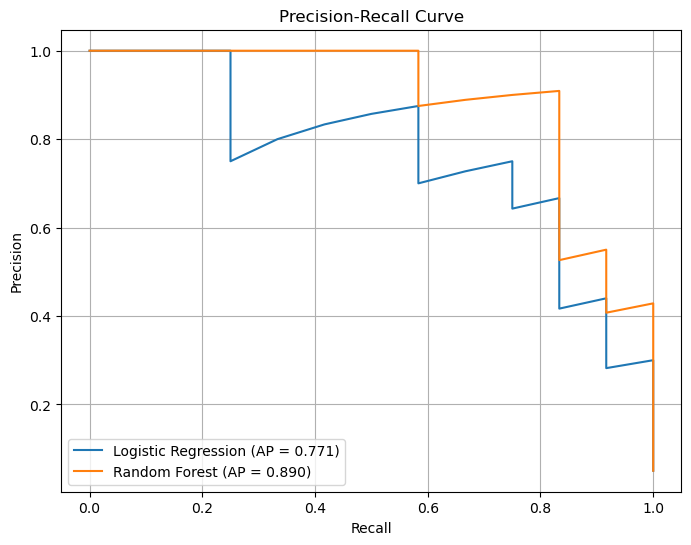

Logistic Regression Average Precision: 0.7707846320346321
Random Forest Average Precision: 0.8897126022126022


In [28]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Logistic Regression probabilities
y_prob_lr = lr_probs

# Random Forest probabilities
y_prob_rf = rf_grid.predict_proba(X_test)[:, 1]

# Precision-Recall values
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

# Average Precision
ap_lr = average_precision_score(y_test, y_prob_lr)
ap_rf = average_precision_score(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    recall_lr,
    precision_lr,
    label=f"Logistic Regression (AP = {ap_lr:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

print("Logistic Regression Average Precision:", ap_lr)
print("Random Forest Average Precision:", ap_rf)

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Random Forest fraud probabilities
y_prob_rf = rf_grid.predict_proba(X_test)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

threshold_results_rf = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_rf >= threshold).astype(int)

    threshold_results_rf.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "F1-Score": f1_score(
            y_test, y_pred_threshold, zero_division=0
        )
    })

rf_threshold_df = pd.DataFrame(threshold_results_rf)

rf_threshold_df

,Threshold,Precision,Recall,F1-Score
0,0.10,0.342857,1.000000,0.510638
1,0.15,0.458333,0.916667,0.611111
2,0.20,0.550000,0.916667,0.687500
3,0.25,0.714286,0.833333,0.769231
4,0.30,0.714286,0.833333,0.769231
5,0.35,0.833333,0.833333,0.833333
6,0.40,0.900000,0.750000,0.818182
7,0.45,0.888889,0.666667,0.761905
8,0.50,1.000000,0.583333,0.736842


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

# Logistic Regression predictions/probabilities
y_pred_lr = (lr_probs >= 0.5).astype(int)

# Random Forest default threshold
y_pred_rf_default = (y_prob_rf >= 0.50).astype(int)

# Random Forest selected threshold
y_pred_rf_final = (y_prob_rf >= 0.35).astype(int)

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest (0.50)",
        "Random Forest (0.35)"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, lr_probs),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "Average Precision": [
        average_precision_score(y_test, lr_probs),
        average_precision_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf_default, zero_division=0),
        precision_score(y_test, y_pred_rf_final, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf_default, zero_division=0),
        recall_score(y_test, y_pred_rf_final, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf_default, zero_division=0),
        f1_score(y_test, y_pred_rf_final, zero_division=0)
    ]
})

comparison.round(4)

,Model,ROC-AUC,Average Precision,Precision,Recall,F1-Score
0,Logistic Regression,0.9792,0.7708,0.3143,0.9167,0.4681
1,Random Forest (0.50),0.9898,0.8897,1.0000,0.5833,0.7368
2,Random Forest (0.35),0.9898,0.8897,0.8333,0.8333,0.8333


In [31]:
from sklearn.metrics import confusion_matrix, classification_report

# Final predictions using selected threshold
y_pred_final = (y_prob_rf >= 0.35).astype(int)

print("=== Final Model: Random Forest (Threshold = 0.35) ===")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

=== Final Model: Random Forest (Threshold = 0.35) ===

Confusion Matrix:
[[226   2]
 [  2  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       228
           1       0.83      0.83      0.83        12

    accuracy                           0.98       240
   macro avg       0.91      0.91      0.91       240
weighted avg       0.98      0.98      0.98       240



## Final Conclusion

This project developed a machine learning pipeline for identifying potentially fraudulent transactions in the sales dataset. The workflow included data preprocessing, feature engineering, class-imbalance handling using SMOTE, model training, hyperparameter tuning, and evaluation using fraud-focused metrics.

Two classification models were evaluated: Logistic Regression and Random Forest. Logistic Regression achieved a test ROC-AUC of 0.9792 and fraud recall of 91.7%, but its fraud precision was relatively low at 31.4%. Random Forest achieved a higher test ROC-AUC of 0.9898 and Average Precision of 0.8897, demonstrating stronger overall discrimination and precision-recall performance.

The default Random Forest threshold of 0.50 produced 100% fraud precision but only 58.3% recall. After threshold analysis, a threshold of 0.35 provided a better balance, achieving 83.3% precision, 83.3% recall, and 83.3% F1-score for the fraud class.

At the selected threshold of 0.35, the final Random Forest model produced 226 true negatives, 2 false positives, 2 false negatives, and 10 true positives on the test set. Overall accuracy was 98.3%.

Based on the evaluated metrics, Random Forest with a classification threshold of 0.35 was selected as the final model because it provided the strongest balance between detecting fraudulent transactions and limiting false fraud alerts.

### Limitations

The test set contained only 12 positive fraud cases, so the reported fraud-class metrics may be sensitive to a small number of predictions. Therefore, the results should be interpreted cautiously and should not be considered definitive evidence of real-world fraud detection performance.

In addition, the fraud target in this project was derived from the available dataset rather than being a verified ground-truth fraud label. Consequently, the model should be interpreted as detecting transactions matching the project's defined fraud criteria rather than confirmed real-world fraud.

### Future Improvements

Future work could include collecting a larger dataset with verified fraud labels, using time-based validation, testing additional ensemble models, optimizing the decision threshold using a separate validation set, and evaluating the model using cost-sensitive metrics based on the financial impact of false positives and false negatives.